<a href="https://colab.research.google.com/github/deburg0/SysBioCellSig/blob/main/Chap04/Sec4.2NonDim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simplifying the notation for the activated complex: $c_{xy} \rightarrow c$, we have

$$\ce{x + y <=>[k_1][k_{-1}]c}$$

With initial conditions, $x,y,c = x_0,y_0,c_0=0$
$$
\begin{align}
\dot{x} &= -k_1 x y + k_{-1} c \\
\dot{y} &= -k_1 x y + k_{-1} c \\
\dot{c} &= k_1 x y - k_{-1} c \\
\end{align}
$$


The following variables are conserved
$$
\begin{align}
\dot{x} + \dot{c} = 0 &\implies x + c = x_0 \\
\dot{y} + \dot{c} = 0 &\implies y + c = y_0 \\
\end{align}
$$

Accordingly, we can rewrite the ODE for the complex as
$$
\dot{c} = k_1 (x_0 - c) (y_0 - c) - k_{-1} c $$

Convert to nondimensional variables:
$$
\begin{align}
c &\rightarrow y_0 c \\
\frac{d}{dt} &\rightarrow k_1 y_0 \frac{d}{dt} \\
\end{align}
$$

This process results in the dimensionless parameters
$$
\begin{align}
\xi_0 &= \frac{x_0}{y_0} \\
\kappa_1 &={ k_{-1} \over k_1 y_0} \\
\end{align}
$$

Finally, we obtain the nondimensional equation
$$
\dot{c} = (\xi_0 - c) (1 - c) - \kappa_1 c $$

The equilibrium condition, satisfies the quadratic equation
$$
c^2 - (1 + \xi_0 + \kappa_1)c + \xi_0 = 0$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from math import sqrt

In [3]:
plt.rcParams.update({
    'axes.labelsize': 18,
    'axes.linewidth': 2.0,
    'lines.linewidth': 1.5,
    'font.size': 18,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2,
    'ytick.major.width': 2,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


In [4]:
def eq(ξ0,κ1):
    mb = 1 + ξ0 + κ1
    disc = mb**2 - 4*ξ0

    return ( (mb - np.sqrt(disc))/2, (mb + np.sqrt(disc))/2 )

In [5]:
x0,y0,k1,k_1 = (14,9,1,2)

In [6]:
eq(x0/y0,k_1/(k1*y0)), (x0+y0)/y0

((np.float64(0.7777777777777778), np.float64(2.0)), 2.5555555555555554)

In [7]:
X0 = np.linspace(0.5,2, 100)

In [8]:
y0,k1,k_1 = (1,1.5,0.5)

In [9]:
cm,cp = eq(X0/y0,k_1/(k1*y0))

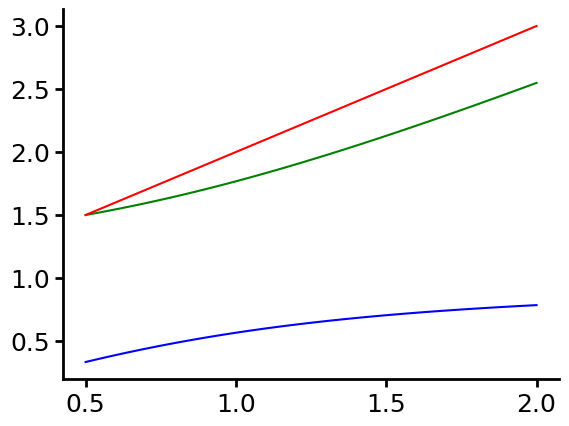

In [10]:
plt.plot(X0/y0, cm, 'b')
plt.plot(X0/y0, cp, 'g')
plt.plot(X0/y0, (X0+y0)/y0, 'r')
plt.show()

In [11]:
x0 = 1.5

In [12]:
c = np.linspace(0,1.1*(x0+y0)/y0, 101)

In [13]:
def f(t,X, ξ0,κ1):
    c, = X
    dcdt = (ξ0 - c)*(1 - c) - κ1*c

    return [dcdt]

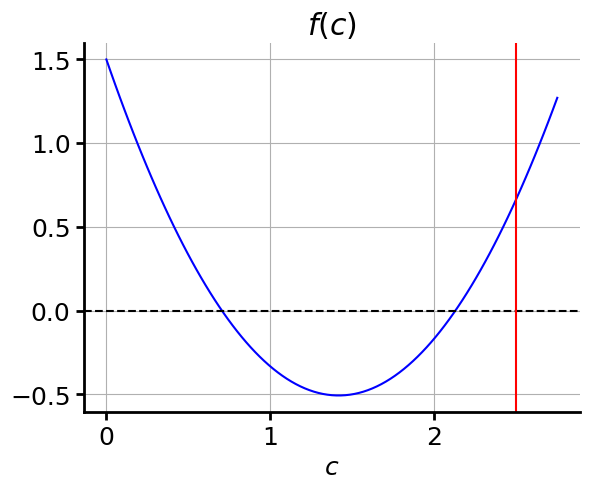

In [14]:
plt.plot(c, f(0,[c], x0/y0, k_1/(k1*y0))[0] , 'b')
plt.axhline( ls='--', color='k')
plt.axvline((x0+y0)/y0, color='r')
plt.xlabel(r"$c$")
plt.grid()
plt.title(r"$f(c)$")
plt.show()

In [15]:
def J(X, ξ0,κ1):
    c, = X
    dfdc = 2*c - (1 + ξ0 + κ1)

    return [dfdc]

In [16]:
k1,k_1

(1.5, 0.5)

In [17]:
cm,cp = eq(x0/y0,k_1/(k1*y0))

In [18]:
J([cm], x0/y0,k_1/(k1*y0))

[np.float64(-1.4240006242195888)]

In [19]:
J([np.array([cm,cp])], x0/y0,k_1/(k1*y0))

[array([-1.42400062,  1.42400062])]

In [20]:
[cm,cp], (x0+y0)/y0

([np.float64(0.7046663545568723), np.float64(2.128666978776461)], 2.5)

In [21]:
def implicit(c, ξ0,κ1):

    D = (1 + ξ0 + κ1)**2 - 4*ξ0
    sqrtD = sqrt(D)

    return (np.log( ( (1 + ξ0 + κ1 - sqrtD)*c - 2*ξ0 ) / ( (1 + ξ0 + κ1 + sqrtD)*c - 2*ξ0 ) ) / sqrtD )

In [22]:
x0,y0,k1,k_1

(1.5, 1, 1.5, 0.5)

In [23]:
cm,cp

(np.float64(0.7046663545568723), np.float64(2.128666978776461))

In [24]:
implicit(0.5, x0/y0,k_1/(k1*y0))

np.float64(0.6802028225366306)

In [25]:
implicit(0.6, x0/y0,k_1/(k1*y0))

np.float64(1.106633550883756)

In [26]:
implicit(0.7, x0/y0,k_1/(k1*y0))

np.float64(3.2433919429869342)

In [27]:
implicit(cm-1.e-16, x0/y0,k_1/(k1*y0))

np.float64(25.31395856380336)

In [28]:
from scipy.integrate import solve_ivp

In [29]:
tEnd = 25.31
t = np.linspace(0,tEnd, int(100*tEnd)+1)
t[-5:]

array([25.27, 25.28, 25.29, 25.3 , 25.31])

In [30]:
soln = solve_ivp(f, [0, tEnd], [0], args=(x0/y0, k_1/(k1*y0),), method='Radau', t_eval=t)
soln

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  2.530e+01  2.531e+01]
        y: [[ 0.000e+00  1.479e-02 ...  7.047e-01  7.047e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 117
     njev: 2
      nlu: 32

In [31]:
c, = soln.y

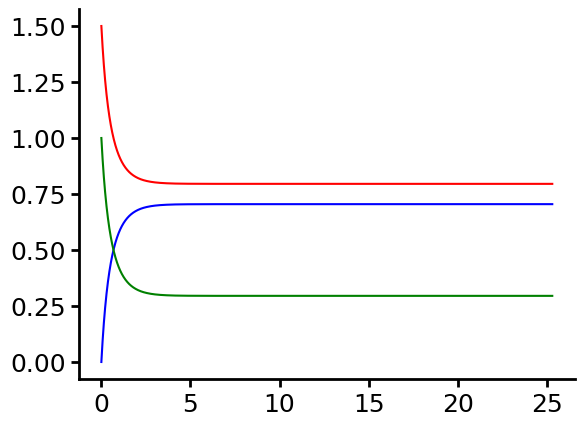

In [32]:
plt.plot(t,c, 'b')
plt.plot(t,(1-c), 'g')
plt.plot(t, (x0/y0 - c), 'r')
plt.show()